### Use of AI
ChatGPT has been used as help, along with existing documentation in completing the tasks. Some tasks have been completed only by reviewing and applying existing documentation (without AI). The use of AI has been avoided when I was able to solve the tasks only with the use of previous logic applied in earlier tasks or documentation help was sufficient.

## Task 0

a) 
Dataset name: Global Financial Markets Dataset (2000-Present)
Link: https://www.kaggle.com/datasets/belbino/global-financial-markets-dataset-2010-present 

b) The dataset provides daily OHLCV (Open, High, Low, Close, Volume) data for 34 major financial assets spanning four asset classes: Stock Indices, Cryptocurrencies, Commodities, and Currency pairs (Forex). It is a single CSV file containing 185,000+ daily OHLCV records (rows) for 34 global financial assets from 2000-01-01 to yesterday. Rows are sorted by date. Each row represents one trading day for one asset. For my project, the plan is to analyze how different markets react to major global economic events. The dataset contains the following variables:

**date**,
**open**,
**high**,
**low**,
**close**,
**volume**,
**symbol**,
**asset_name**,
**asset_type**,
**region**

,open,high,low,close,volume
count,4225.000000,4225.000000,4225.000000,4225.000000,4.225000e+03
mean,28001.746075,28561.466098,27406.276907,28017.914428,2.213451e+10
std,32186.037386,32733.215825,31595.410550,32190.034466,2.300376e+10
min,176.897000,211.731000,171.510000,178.103000,5.914570e+06
25%,3236.274700,3305.753200,3155.600100,3242.484900,1.512450e+09
50%,11322.570300,11545.615200,11002.400400,11323.466800,1.760379e+10
75%,44096.703100,45077.578100,43232.968800,44162.691400,3.425096e+10
max,124752.140600,126198.070300,123196.046900,124752.531200,3.509679e+11


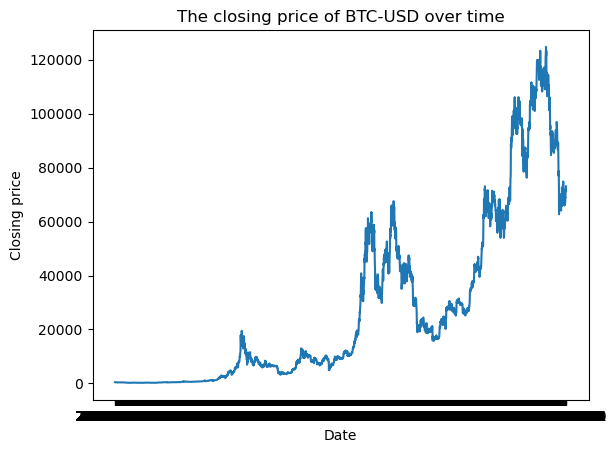

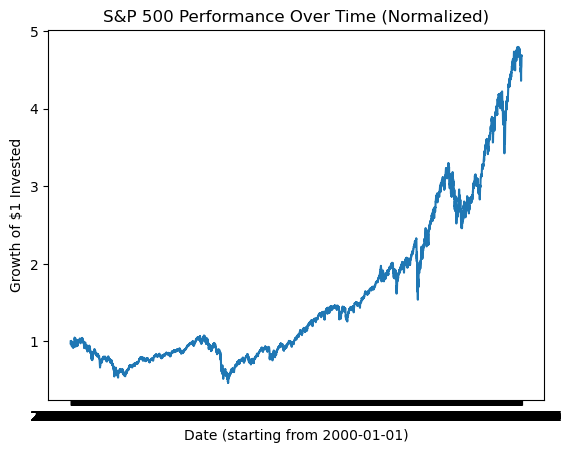

In [1]:
#c)

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

df = pd.read_csv("global_financial_markets_2000_Now.csv")

#Calling .describe on all rows which include the ticker 'BTC-USD'
ticker = 'BTC-USD'
ticker_df = df[df['symbol'] == ticker]
display(ticker_df.describe())

#Visual 1
#Configuring visual of the development of 'BTC-USD' price over time
plt.figure()
#Selecting columns 'date' and 'close' from the dataset
plt.plot(ticker_df['date'], ticker_df['close'])

#Naming visual title and axis
plt.title(f"The closing price of {ticker} over time")
plt.xlabel("Date")
plt.ylabel('Closing price')
plt.show()

#Visual 2
#Filtering to only include rows from the S&P 500
asset_name = 'S&P500'
asset_df = df[df['asset_name'] == asset_name].copy()

#Calculating how much the price has changed by dividing each closing price by the first closing price in the dataset
asset_df['normalized_close'] = asset_df['close'] / asset_df['close'].iloc[0]

#Configuring second visual
plt.figure()

#Selecting columns 'date' and 'normalized close'
plt.plot(asset_df['date'], asset_df['normalized_close'])

#Naming visual and axis
plt.title('S&P 500 Performance Over Time (Normalized)')
plt.xlabel('Date (starting from 2000-01-01)')
plt.ylabel('Growth of $1 Invested')
plt.show()

## Task 2

In [2]:
#a)

import os
import requests
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
api_key = os.getenv("MARKETSTACK_API_KEY")

#Creating list of tickers we want to include in the api request
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

base_url = "http://api.marketstack.com/v1/eod"

#Defining function for fetching the ticker data, and setting the parameters for the api request
def fetch_stock_data(symbol):
    params = {
        "access_key": api_key,
        "symbols": symbol,
        "date_from": "2026-03-01",
        "date_to": "2026-03-31"
    }
    
    #Sending the api request and converting result to python dict
    response = requests.get(base_url, params=params)
    data = response.json()

    #Converting dict to DataFrame and adding symbol column for clarity
    df = pd.DataFrame(data["data"])
    df["symbol"] = symbol
    
    return df

#b)
all_data = []

#Iterating through each ticker, calling the fetch function for each stock, and storing the results in all_data
for ticker in tickers:
    print(f"Fetching {ticker}...")
    df_ticker = fetch_stock_data(ticker)
    all_data.append(df_ticker)

#Combining the Dataframes from all_data into one
faang_df = pd.concat(all_data, ignore_index=True)

faang_df.head()

Fetching META...
Fetching AAPL...
Fetching AMZN...
Fetching NFLX...
Fetching GOOG...


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30T00:00:00+0000
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27T00:00:00+0000
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26T00:00:00+0000
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25T00:00:00+0000


In [3]:
#c)
closing_prices = faang_df.groupby("symbol")["close"].describe()
display(closing_prices)

#Date to datetime and sorting by symbol and date
faang_df["date"] = pd.to_datetime(faang_df["date"])
faang_df = faang_df.sort_values(["symbol", "date"])

#Computing first and last close per stock
returns = faang_df.groupby("symbol")["close"].agg(["first", "last"])

#Calculating percentage return
returns["return_%"] = (returns["last"] - returns["first"]) / returns["first"] * 100

display(returns)

#Printing of best and worst 
best_stock = returns["return_%"].idxmax()
worst_stock = returns["return_%"].idxmin()

print("Monthly returns (%):")
print(returns["return_%"])

print("\nBest performing stock:", best_stock)
print("Worst performing stock:", worst_stock)

,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


,first,last,return_%
symbol,,,
AAPL,264.72,253.79,-4.128891
AMZN,208.39,208.27,-0.057584
GOOG,306.36,286.86,-6.365061
META,653.56,572.13,-12.459453
NFLX,97.09,96.15,-0.968174


Monthly returns (%):
symbol
AAPL    -4.128891
AMZN    -0.057584
GOOG    -6.365061
META   -12.459453
NFLX    -0.968174
Name: return_%, dtype: float64

Best performing stock: AMZN
Worst performing stock: META


## Task 3

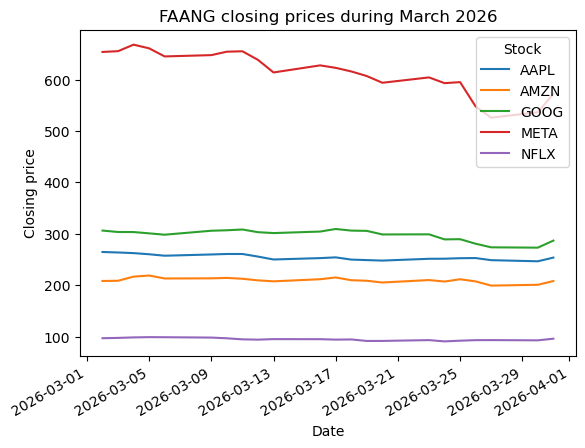

In [4]:
#a)
import seaborn as sb
import matplotlib.pyplot as plt

#Setting parameters for the seaborn lineplot
sb.lineplot(
    data=faang_df,
    x="date",
    y="close",
    hue="symbol"
)

plt.title("FAANG closing prices during March 2026")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.legend(title="Stock")

#Fixing issue where dates on x-axis were crammed together
plt.gcf().autofmt_xdate()
plt.show()

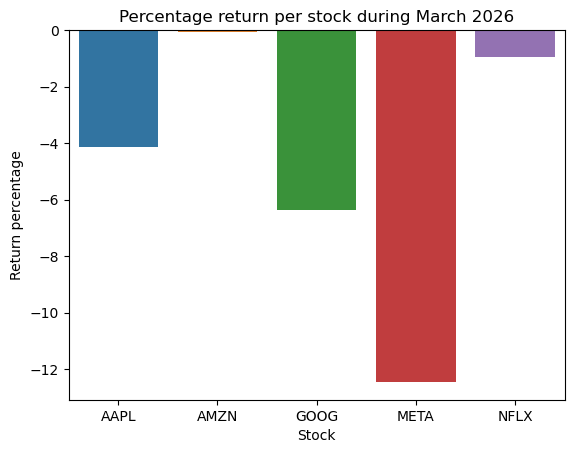

In [5]:
#b)
import seaborn as sb
import matplotlib.pyplot as plt

#Turn symbol from the index in the dataframe to a column
returns_df = returns.reset_index()

sb.barplot(
    data=returns_df,
    x="symbol",
    y="return_%",
    hue="symbol"
)

plt.title("Percentage return per stock during March 2026")
plt.xlabel("Stock")
plt.ylabel("Return percentage")
plt.show()

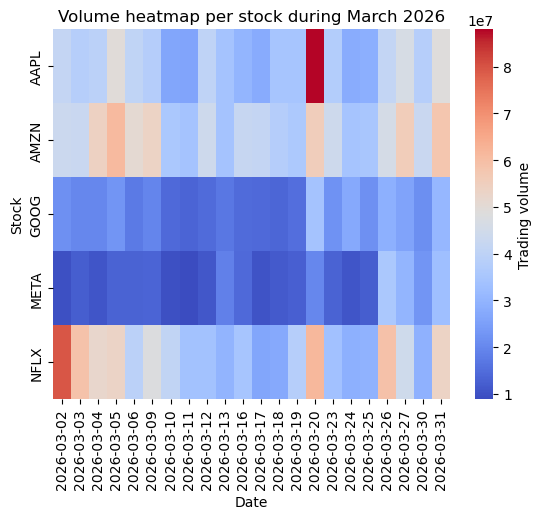

In [6]:
#c)
import seaborn as sb
import matplotlib.pyplot as plt

#Formatting dates to improve readability by removing full timestamp
faang_df["date_str"] = faang_df["date"].dt.strftime("%Y-%m-%d")

volume_pivot = faang_df.pivot(
    index="symbol",
    columns="date_str",
    values="volume"
)

sb.heatmap(
    volume_pivot,
    cmap="coolwarm",
    cbar_kws={"label": "Trading volume"}
)

plt.title("Volume heatmap per stock during March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.show()

## Task 4

In [7]:
#a)
import os

os.makedirs("exports", exist_ok=True)

faang_df.to_json("exports/stockdata.json", orient="records", indent=4)

In [8]:
#b)
import os

faang_df.to_csv("exports/stockdata.csv", index=False)

In [9]:
#c)
import pandas as pd

exported_json_df = pd.read_json("exports/stockdata.json")
exported_csv_df = pd.read_csv("exports/stockdata.csv")

display(exported_json_df.head())
display(exported_csv_df.head())

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date,date_str
0,262.440,266.530,260.20,264.72,41576035,266.530,260.20,264.72,262.41,41827946,1,0.0,AAPL,XNAS,2026-03-02,2026-03-02
1,263.480,265.560,260.13,263.75,37994695,265.560,260.13,263.75,263.48,38568921,1,0.0,AAPL,XNAS,2026-03-03,2026-03-03
2,264.650,266.150,261.42,262.52,39258957,266.150,261.42,262.52,264.65,39803119,1,0.0,AAPL,XNAS,2026-03-04,2026-03-04
3,260.745,261.555,257.25,260.29,49424671,261.555,257.25,260.29,260.79,49658626,1,0.0,AAPL,XNAS,2026-03-05,2026-03-05
4,258.740,258.760,254.37,257.46,40628988,258.770,254.37,257.46,258.63,41120042,1,0.0,AAPL,XNAS,2026-03-06,2026-03-06


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date,date_str
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02 00:00:00+00:00,2026-03-02
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,AAPL,XNAS,2026-03-03 00:00:00+00:00,2026-03-03
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04 00:00:00+00:00,2026-03-04
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05 00:00:00+00:00,2026-03-05
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06 00:00:00+00:00,2026-03-06


## Task 5

In [10]:
#a)
import sqlite3

db = sqlite3.connect("northwind.db")

db.execute(
    "SELECT name FROM sqlite_master WHERE type='table'"
).fetchall()

[('Categories',),
 ('sqlite_sequence',),
 ('CustomerCustomerDemo',),
 ('CustomerDemographics',),
 ('Customers',),
 ('Employees',),
 ('EmployeeTerritories',),
 ('Order Details',),
 ('Orders',),
 ('Products',),
 ('Regions',),
 ('Shippers',),
 ('Suppliers',),
 ('Territories',)]

In [11]:
#b)
import sqlite3
import pandas as pd

#Querying to get all products with a UnitPrice above 30
product_data = db.execute(
    "SELECT ProductName, UnitPrice, UnitsInStock FROM Products WHERE UnitPrice > 30"
)

df = pd.DataFrame(product_data, columns=["ProductName", "UnitPrice", "UnitsInStock"])

display(df)

,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


In [12]:
#c)
import sqlite3
import pandas as pd

#Querying to get LineTotal for all orders shipped to Germany
shipped_to_ger = pd.read_sql_query("""
    SELECT 
        c.CompanyName, 
        o.OrderID, 
        o.OrderDate, 
        o.ShipCountry, 
        od.UnitPrice * od.Quantity AS LineTotal
    FROM Orders o
    JOIN Customers c ON c.CustomerID = o.CustomerID
    JOIN "Order Details" od ON od.OrderID = o.OrderID
    WHERE o.ShipCountry = 'Germany'
""", db)

display(shipped_to_ger)

,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


## Task 6

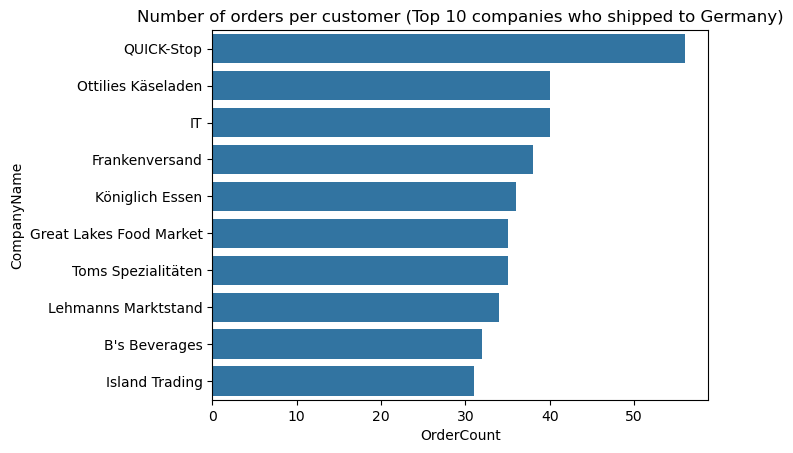

In [13]:
#a)
import seaborn as sb
import matplotlib.pyplot as plt

#Grouping dataframe by CompanyName and OrderID
orders_per_customer = (
    shipped_to_ger.groupby("CompanyName")["OrderID"]

    #Each order is counted once per customer
    .nunique()
    .sort_values(ascending=False)
    .head(10)

    #Moving CompanyName into a column and naming the ordercount column
    .reset_index(name="OrderCount")
)

sb.barplot(
    data=orders_per_customer,
    x="OrderCount",
    y="CompanyName"
)

plt.title("Number of orders per customer (Top 10 companies who shipped to Germany)")
plt.show()

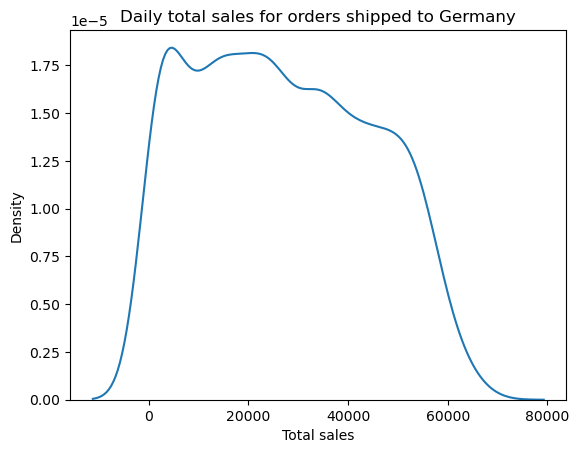

In [14]:
#b)
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd

sales_per_date = (
    shipped_to_ger.groupby("OrderDate")["LineTotal"]
    .sum()
    .reset_index()
)

sb.kdeplot(
    data=sales_per_date,
    x="LineTotal"
)

plt.title("Daily total sales for orders shipped to Germany")
plt.xlabel("Total sales")
plt.show()

,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


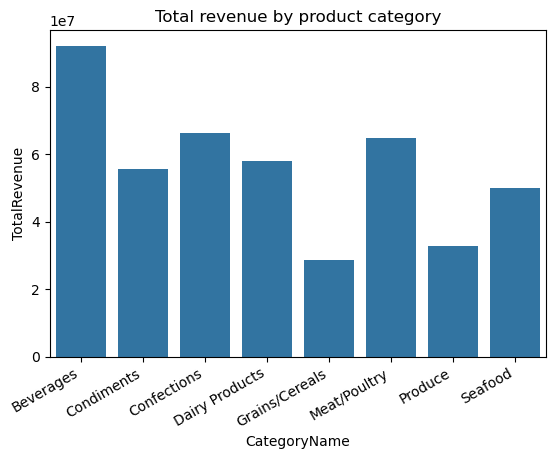

In [15]:
#c)
import seaborn as sb
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#Querying to retreive total revenue by CategoryName
total_revenue = pd.read_sql_query("""
    SELECT 
        cat.CategoryName, 
        SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM 'Order Details' od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
""", db)

display(total_revenue)

sb.barplot(
    data=total_revenue,
    x="CategoryName",
    y="TotalRevenue"
)

#Preventing x-axis names from getting crammed together
plt.gcf().autofmt_xdate()
plt.title("Total revenue by product category")
plt.show()

## Task 7

In [16]:
#a)
products_df = pd.read_sql_query("""
    SELECT *
    FROM Products
""", db)

categories_df = pd.read_sql_query("""
    SELECT *
    FROM Categories
""", db)

display(products_df.head())
display(categories_df.head())

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [17]:
#b)
cat_p = products_df.merge(
    categories_df,
    on="CategoryID",
    how="inner"
)

display(cat_p.head())

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


In [18]:
#c)
import time

#Starting measurement of execution speed
start_time1 = time.time()

#Querying to retrieve only full tables
od = pd.read_sql_query("""
    SELECT *
    FROM "Order Details"
""", db)

p = pd.read_sql_query("""
    SELECT *
    FROM Products
""", db)

cat = pd.read_sql_query("""
    SELECT *
    FROM Categories
""", db)

#Merging tables using pandas
od_p = od.merge(
    p,
    on="ProductID",
    how="inner",
    #Differentiating between UnitPrice from the table Order Details and UnitPrice from Products
    suffixes=("_order", "_product")
)

od_p_cat = od_p.merge(
    cat,
    on="CategoryID",
    how="inner"
)

#Computing new column TotalRevenue
od_p_cat["TotalRevenue"] = od_p_cat["UnitPrice_order"] * od_p_cat["Quantity"]

#Dataframe as in Task 6c)
total_revenue_df = (
    od_p_cat
    .groupby("CategoryName", as_index = False)["TotalRevenue"]
    .sum()
)

display(total_revenue_df)

#Stopping measurement of execution speed and calculating result
end_time1 = time.time()
print(f"Execution time: {end_time1 - start_time1:.2f} seconds")


start_time2 = time.time()

#Copied query from Task 6c) to compare execution times
total_revenue = pd.read_sql_query("""
    SELECT 
        cat.CategoryName, 
        SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM 'Order Details' od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
""", db)

display(total_revenue)

end_time2 = time.time()
print(f"Execution time: {end_time2 - start_time2:.2f} seconds")

#Performing the full query through SQL-only was significantly faster than first querying the db for full tables and then joining using pandas.

,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


Execution time: 0.57 seconds


,CategoryName,TotalRevenue
0,Beverages,92181842.95
1,Condiments,55802774.45
2,Confections,66347544.94
3,Dairy Products,58034940.00
4,Grains/Cereals,28573512.55
5,Meat/Poultry,64896314.41
6,Produce,32706403.90
7,Seafood,49931965.52


Execution time: 0.20 seconds


## Task 8

In [19]:
#a)
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

display(wide_data)

#Converting from wide to long
wide_to_long = pd.melt(
    wide_data,
    id_vars=["store"],
    var_name="Quarter",
    value_name="Revenue"
)

display(wide_to_long)

,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,store,Quarter,Revenue
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


In [20]:
#b)
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

display(long_data)

#Converting from long to wide
long_to_wide = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
)

#Formatting df
long_to_wide.columns.name = None
long_to_wide = long_to_wide.reset_index(drop=False)

display(long_to_wide)

,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


In [21]:
#c)
#Returning both df's to original format
display(wide_to_long)

back_to_wide = wide_to_long.pivot(
    index="store",
    columns="Quarter",
    values="Revenue"
)
#Formatting df
back_to_wide.columns.name = None
back_to_wide = back_to_wide.reset_index(drop=False)
display(back_to_wide)


display(long_to_wide)

back_to_long = pd.melt(
    long_to_wide,
    id_vars=["month"],
    var_name="product",
    value_name="units_sold"
)

display(back_to_long)

,store,Quarter,Revenue
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


,month,Laptop,Phone
0,Feb,50,110
1,Jan,45,120
2,Mar,55,130


,month,product,units_sold
0,Feb,Laptop,50
1,Jan,Laptop,45
2,Mar,Laptop,55
3,Feb,Phone,110
4,Jan,Phone,120
5,Mar,Phone,130
